# 📊 ML and LLM Mental Health

### 👩‍💻 Author: Hafsa Hoque Tripty  
### 🎓 Department: CSE  
### 📌 Objective:
To build and compare multiple machine learning models for a multiclass classification problem and identify the best-performing model.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score

# Binary Classification



###Dataset Loading
In this step, we load the dataset and inspect its structure.

###Data Preprocessing
This section handles cleaning the raw dataset and converting text labels into numbers that the machine learning models can understand.


In [ ]:
def load_and_clean(file_path, target_mode='binary'):
    df = pd.read_csv(file_path)
# 1. Intensity Mapping (Ordinal)
    ord_map = {'Seldom': 1, 'Sometimes': 2, 'Usually': 3, 'Most-Often': 4}
    for col in ['Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder']:
        df[col] = df[col].map(ord_map)

    # 2. Binary Mapping (Yes/No)
    for col in ['Mood Swing', 'Suicidal thoughts', 'Anorxia', 'Authority Respect', 'Try-Explanation',
                'Aggressive Response', 'Ignore & Move-On', 'Nervous Break-down', 'Admit Mistakes', 'Overthinking']:
        df[col] = df[col].str.strip().map({'YES': 1, 'NO': 0})

    # 3. Numeric Extraction (Scaling)
    for col in ['Sexual Activity', 'Concentration', 'Optimisim']:
        df[col] = df[col].apply(lambda x: int(str(x).split(' ')[0]))

    # 4. Target Definition
    if target_mode == 'binary':
        # CHANGE HERE: Change 'Normal' to 0, everything else to 1
        df['target'] = df['Expert Diagnose'].apply(lambda x: 0 if x == 'Normal' else 1)
    else:
        # Multiclass Logic
        target_map = {'Normal': 0, 'Bipolar Type-1': 1, 'Bipolar Type-2': 2, 'Depression': 3}
        df['target'] = df['Expert Diagnose'].map(target_map)

    X = df.drop(columns=['Patient Number', 'Expert Diagnose', 'target'])
    y = df['target']
    return X, y

X, y = load_and_clean('Dataset-Mental-Disorders.csv', target_mode='binary')


### Exploratory Data Analysis (EDA)
Countplot: Uses sns.countplot to show the balance between "Normal" and "Disorder" cases.

Heatmap: Generates a correlation matrix using sns.heatmap to identify which symptoms (features) are most related.

/tmp/ipykernel_4703/2731573166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


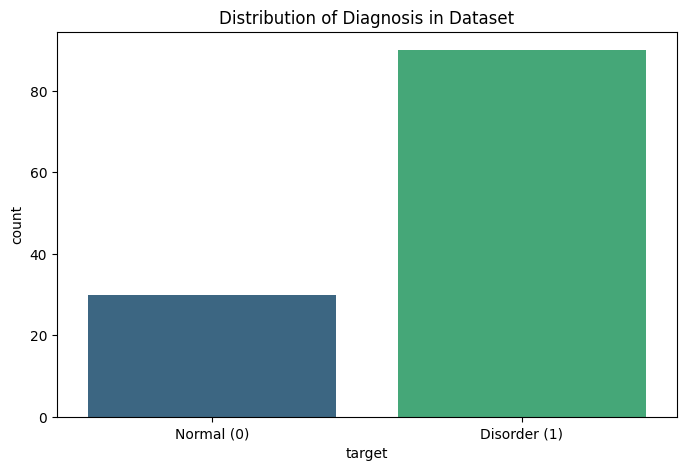

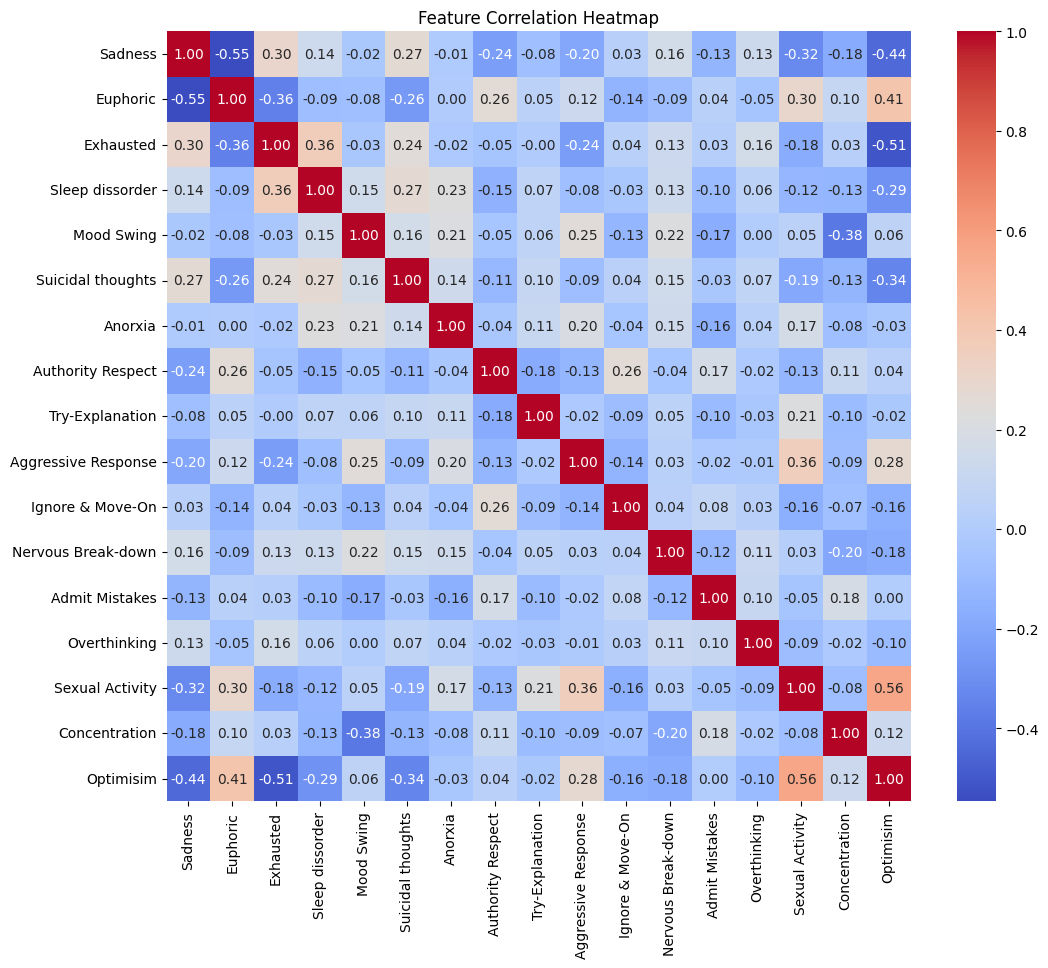

In [ ]:
# Check how many 'Normal' vs 'Disorder' cases we have
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='viridis')
plt.xticks([0, 1], ['Normal (0)', 'Disorder (1)'])
plt.title('Distribution of Diagnosis in Dataset')
plt.show()

# Check for correlations (Which symptoms move together?)
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### **Random Forest**
TRAINING & TUNING (K-FOLD)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2204108)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],  # CHECK VALUE: Keep depth low to avoid overfitting
    'criterion': ['gini', 'entropy']
}

# GridSearchCV finds the best "Knobs" for the model
grid_search = GridSearchCV(RandomForestClassifier(random_state=2204108), param_grid, cv=skf, scoring='recall')
grid_search.fit(X, y)

print(f"Best Parameters Found: {grid_search.best_params_}")
model = grid_search.best_estimator_

Best Parameters Found: {'criterion': 'gini', 'max_depth': 3, 'n_estimators': 50}


###EVALUATION (CONFUSION MATRIX)

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.94      0.94      0.94        18

    accuracy                           0.92        24
   macro avg       0.89      0.89      0.89        24
weighted avg       0.92      0.92      0.92        24



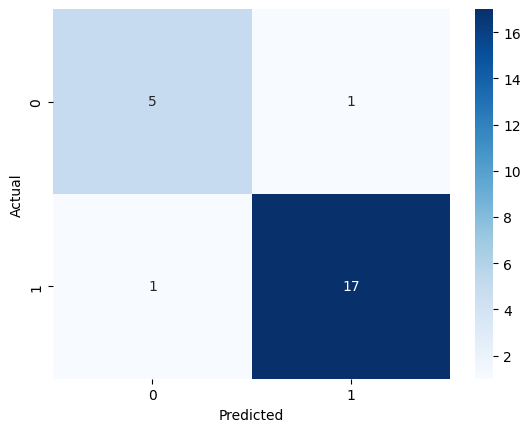

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

###INTERPRETATION (FEATURE IMPORTANCE)

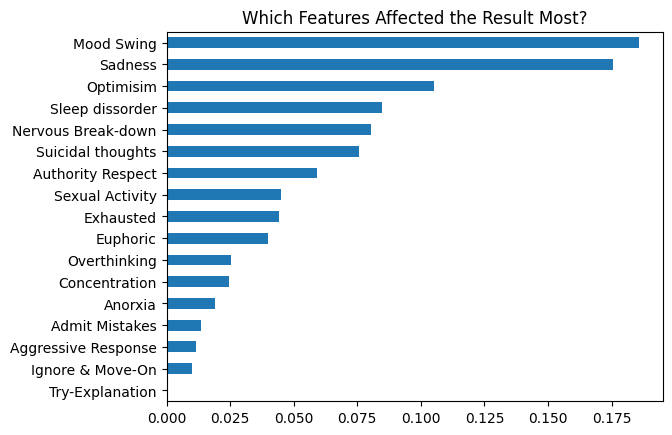

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh')
plt.title('Which Features Affected the Result Most?')
plt.show()

# MULTICLASS CLASSIFICATION (Identifying the Specific Type)

###Data Preprocessing

In [ ]:
def load_and_clean(file_path, target_mode='multiclass'):
    df = pd.read_csv(file_path)

    # 1. Intensity Mapping (Ordinal)
    ord_map = {'Seldom': 1, 'Sometimes': 2, 'Usually': 3, 'Most-Often': 4}
    for col in ['Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder']:
        df[col] = df[col].map(ord_map)

    # 2. Binary Mapping (Yes/No)
    for col in ['Mood Swing', 'Suicidal thoughts', 'Anorxia', 'Authority Respect', 'Try-Explanation',
                'Aggressive Response', 'Ignore & Move-On', 'Nervous Break-down', 'Admit Mistakes', 'Overthinking']:
        df[col] = df[col].str.strip().map({'YES': 1, 'NO': 0})

    # 3. Numeric Extraction (Scaling)
    for col in ['Sexual Activity', 'Concentration', 'Optimisim']:
        df[col] = df[col].apply(lambda x: int(str(x).split(' ')[0]))

    # 4. Target Definition
    if target_mode == 'binary':
        # CHANGE HERE: Change 'Normal' to 0, everything else to 1
        df['target'] = df['Expert Diagnose'].apply(lambda x: 0 if x == 'Normal' else 1)
    else:
        # Multiclass Logic
        target_map = {'Normal': 0, 'Bipolar Type-1': 1, 'Bipolar Type-2': 2, 'Depression': 3}
        df['target'] = df['Expert Diagnose'].map(target_map)

    X = df.drop(columns=['Patient Number', 'Expert Diagnose', 'target'])
    y = df['target']
    return X, y

X, y = load_and_clean('Dataset-Mental-Disorders.csv', target_mode='multiclass')

### Exploratory Data Analysis (EDA)

/tmp/ipykernel_4703/3454028762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


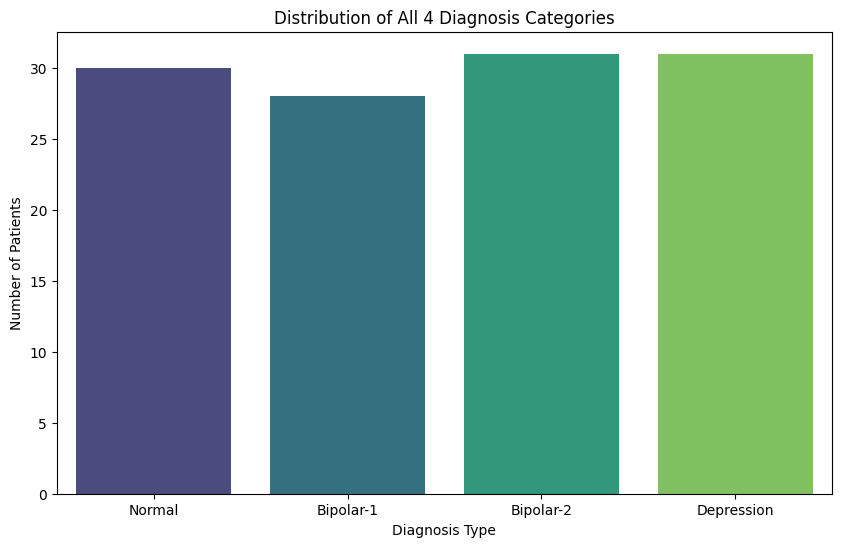

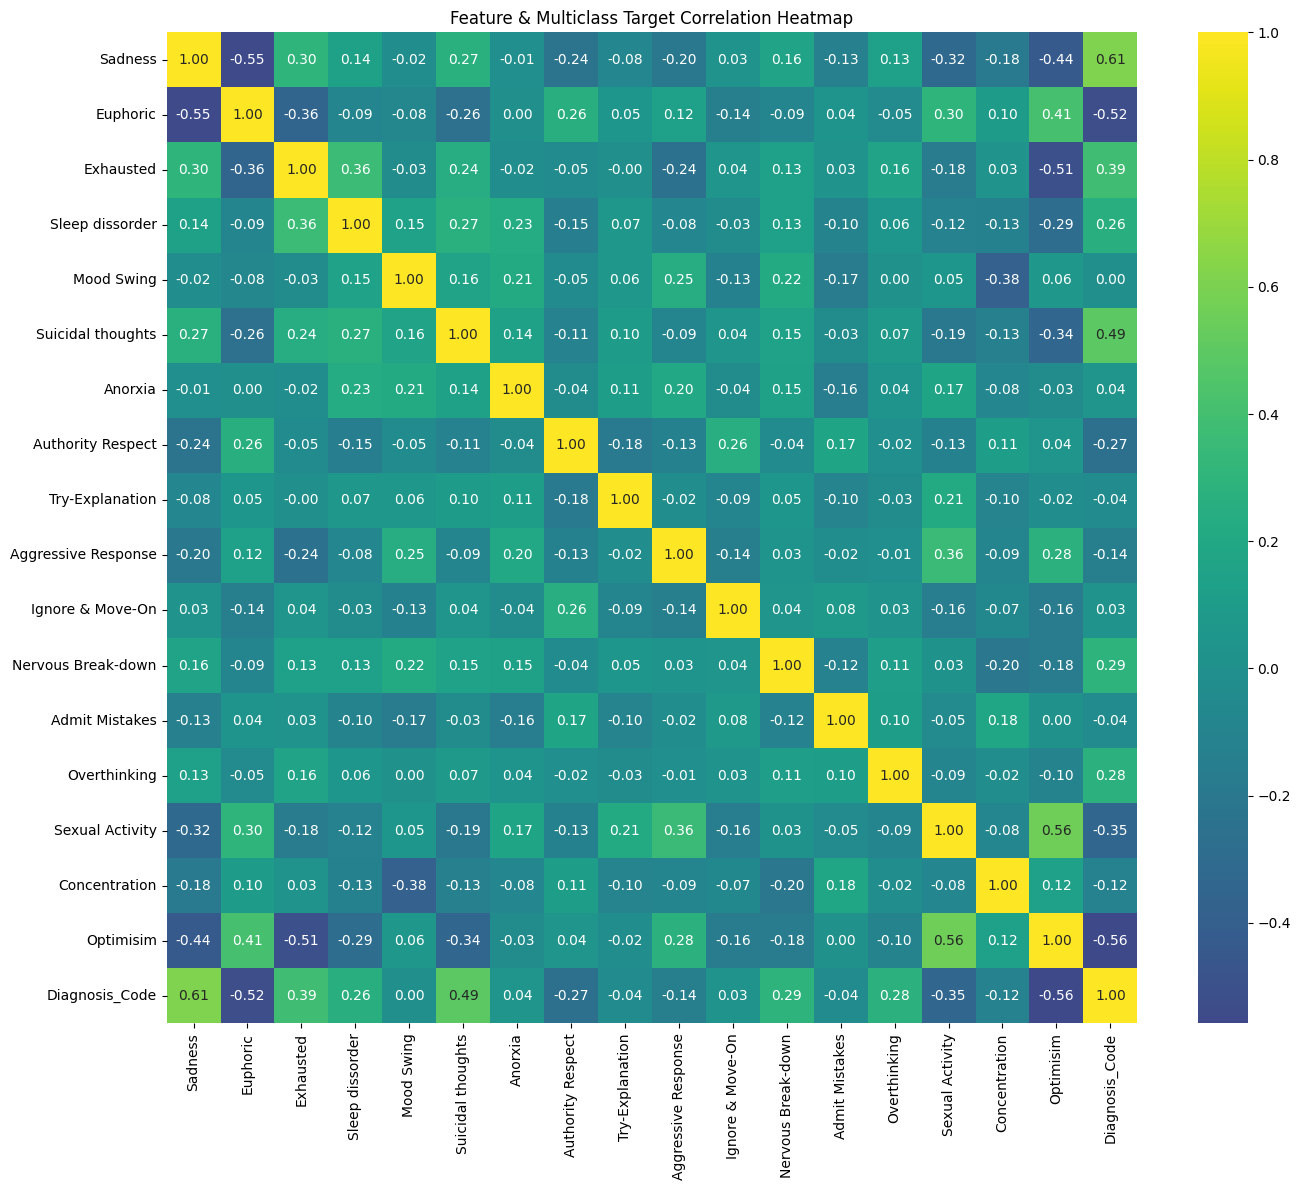

In [ ]:
# 1. Define the class names for labeling
class_names = ['Normal', 'Bipolar-1', 'Bipolar-2', 'Depression']

# 2. Check the distribution of all 4 classes
plt.figure(figsize=(10, 6))
# We use y (which now contains 0, 1, 2, 3)
sns.countplot(x=y, palette='viridis')
plt.xticks(ticks=[0, 1, 2, 3], labels=class_names) # Change from [0,1] to [0,1,2,3]
plt.title('Distribution of All 4 Diagnosis Categories')
plt.xlabel('Diagnosis Type')
plt.ylabel('Number of Patients')
plt.show()

# 3. Check for correlations (Features + Multiclass Target)
plt.figure(figsize=(14, 12))
# It's helpful to see how features correlate with the multiclass target
corr_matrix = X.copy()
corr_matrix['Diagnosis_Code'] = y

sns.heatmap(corr_matrix.corr(), annot=True, cmap='viridis', fmt='.2f', center=0)
plt.title('Feature & Multiclass Target Correlation Heatmap')
plt.tight_layout()
plt.show()

### SPLIT the data first (Raw data)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2204108
)

### FEATURE SCALING (Crucial for LR & KNN)

In [ ]:
# Random Forest doesn't need this, but LR and KNN will fail without it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **LOGISTIC REGRESSION**

### Hyperparameter Tuning

In [ ]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['lbfgs', 'liblinear'] # Algorithm to use in the optimization
}
grid_lr = GridSearchCV(LogisticRegression( max_iter=1000),
                       lr_params, cv=skf, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)

print("--- Hyperparameter Tuning Results ---")
print(f"Best LR Params: {grid_lr.best_params_} ")

model= grid_lr.best_estimator_


--- Hyperparameter Tuning Results ---
Best LR Params: {'C': 0.1, 'solver': 'liblinear'} 


### EVALUATION (SPLIT & PREDICT)

In [ ]:


model.fit(X_train_scaled, y_train)
y_pred_lr = model.predict(X_test_scaled)

# Print Detailed Metrics
print("\nMulticlass Classification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=class_names))



Multiclass Classification Report:

              precision    recall  f1-score   support

      Normal       0.67      1.00      0.80         6
   Bipolar-1       1.00      0.67      0.80         6
   Bipolar-2       1.00      1.00      1.00         6
  Depression       0.80      0.67      0.73         6

    accuracy                           0.83        24
   macro avg       0.87      0.83      0.83        24
weighted avg       0.87      0.83      0.83        24



### VISUALIZATION (CONFUSION MATRIX & IMPORTANCE)

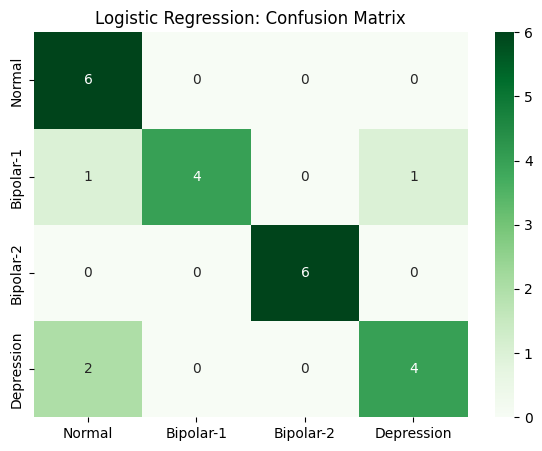

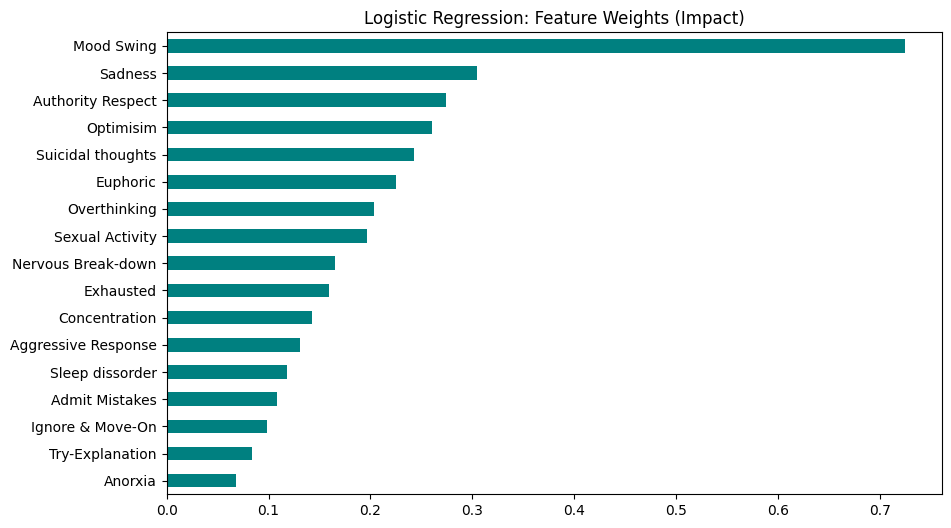

In [ ]:
# LR Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, cmap='Greens', fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Logistic Regression: Confusion Matrix')
plt.show()

# LR Coefficients (Importance)
# We take the mean of absolute coefficients across all 4 classes
weights = np.mean(np.abs(model.coef_), axis=0)
importances_lr = pd.Series(weights, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances_lr.plot(kind='barh', color='teal')
plt.title('Logistic Regression: Feature Weights (Impact)')
plt.show()

## **K-Nearest Neighbors(KNN)**

### HYPERPARAMETER TUNING

In [ ]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11], # Number of neighbors
    'weights': ['uniform', 'distance'], # Weight function used in prediction
    'metric': ['euclidean', 'manhattan'] # Distance metric
}
grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=skf, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

print("--- Hyperparameter Tuning Results ---")
print(f"Best KNN Params: {grid_knn.best_params_} ")

model= grid_knn.best_estimator_

--- Hyperparameter Tuning Results ---
Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'} 


### EVALUATION (SPLIT & PREDICT)

In [ ]:


model.fit(X_train_scaled, y_train)
y_pred_knn = model.predict(X_test_scaled)

# Print Detailed Metrics
print("\nMulticlass Classification Report:\n")
print(classification_report(y_test, y_pred_knn, target_names=class_names))


Multiclass Classification Report:

              precision    recall  f1-score   support

      Normal       0.55      1.00      0.71         6
   Bipolar-1       1.00      0.50      0.67         6
   Bipolar-2       1.00      0.83      0.91         6
  Depression       0.80      0.67      0.73         6

    accuracy                           0.75        24
   macro avg       0.84      0.75      0.75        24
weighted avg       0.84      0.75      0.75        24



### VISUALIZATION (CONFUSION MATRIX & IMPORTANCE)

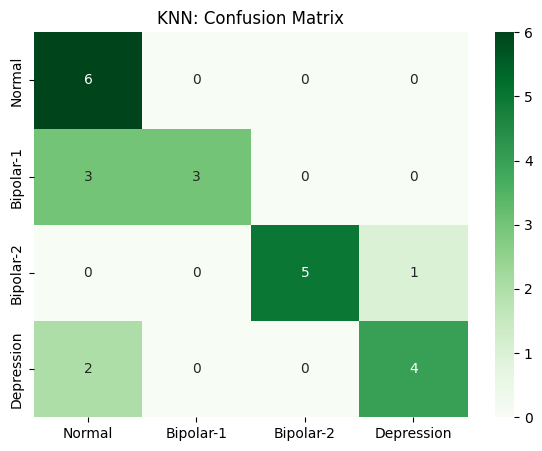

Note: KNN does not provide Feature Importance scores by default.


In [ ]:
# KNN Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, cmap='Greens', fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.title('KNN: Confusion Matrix')
plt.show()

print("Note: KNN does not provide Feature Importance scores by default.")

## **Random Forest Classifier**

### HYPERPARAMETER TUNING (GRID SEARCH)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2204108)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'criterion': ['gini', 'entropy']
}

# In multiclass, we use 'accuracy' or 'f1_weighted' as the scoring metric
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=2204108),
    param_grid,
    cv=skf,
    scoring='accuracy'
)

grid_search.fit(X, y)
print(f"Best Multiclass Parameters: {grid_search.best_params_}")

# Get the best optimized model
model = grid_search.best_estimator_

Best Multiclass Parameters: {'criterion': 'gini', 'max_depth': 3, 'n_estimators': 50}


### EVALUATION (SPLIT & PREDICT)

In [ ]:


model.fit(X_train, y_train)
y_pred_rf = model.predict(X_test)

# Print Detailed Metrics
print("\nMulticlass Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=class_names))


Multiclass Classification Report:

              precision    recall  f1-score   support

      Normal       0.67      1.00      0.80         6
   Bipolar-1       1.00      0.67      0.80         6
   Bipolar-2       1.00      1.00      1.00         6
  Depression       1.00      0.83      0.91         6

    accuracy                           0.88        24
   macro avg       0.92      0.88      0.88        24
weighted avg       0.92      0.88      0.88        24



### VISUALIZATION (CONFUSION MATRIX & IMPORTANCE)

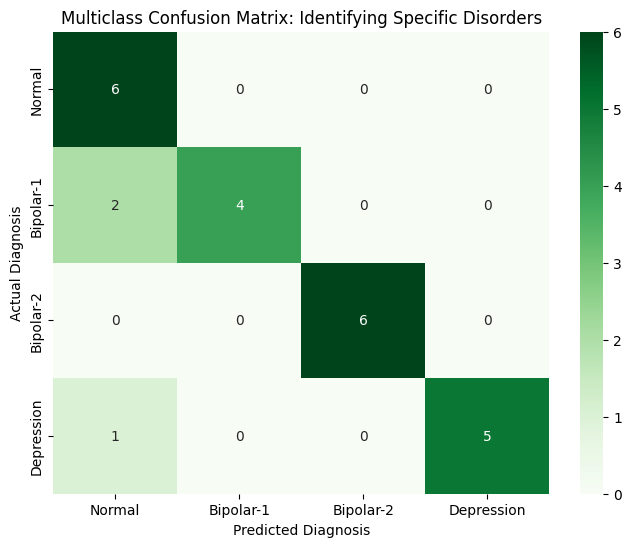

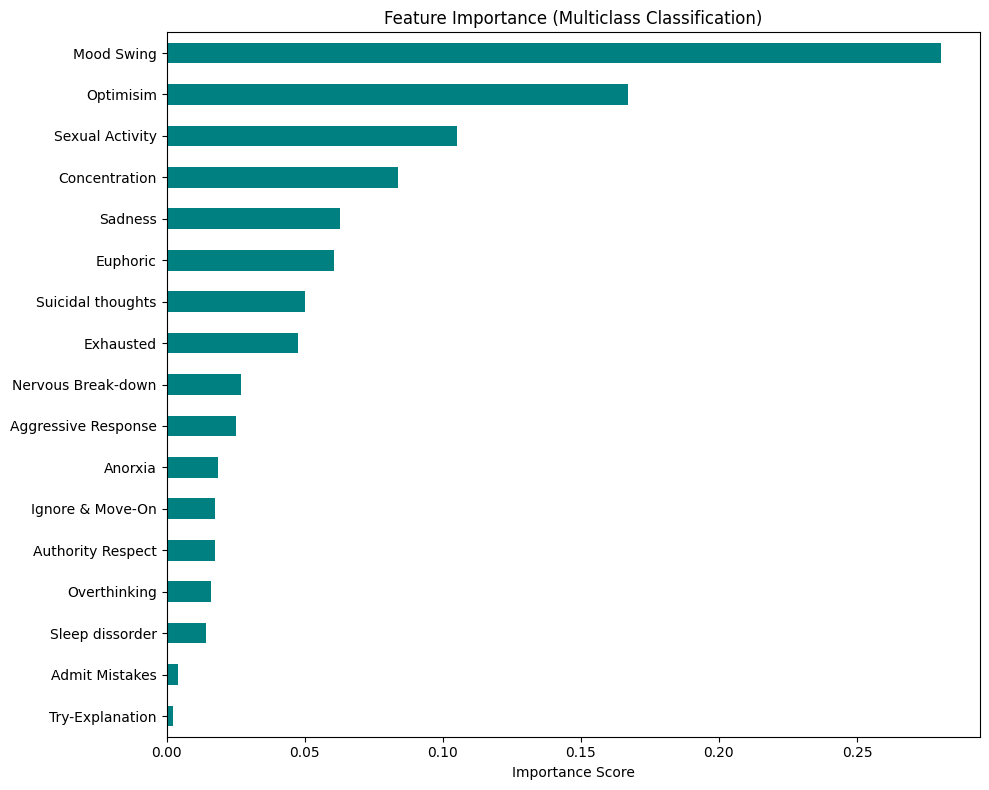

In [ ]:
# Multiclass Confusion Matrix (4x4)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, cmap='Greens', fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multiclass Confusion Matrix: Identifying Specific Disorders')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Final Feature Importance for Multiclass
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance (Multiclass Classification)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Comparative Visualization : Multiclass Accuracy vs F1 Score

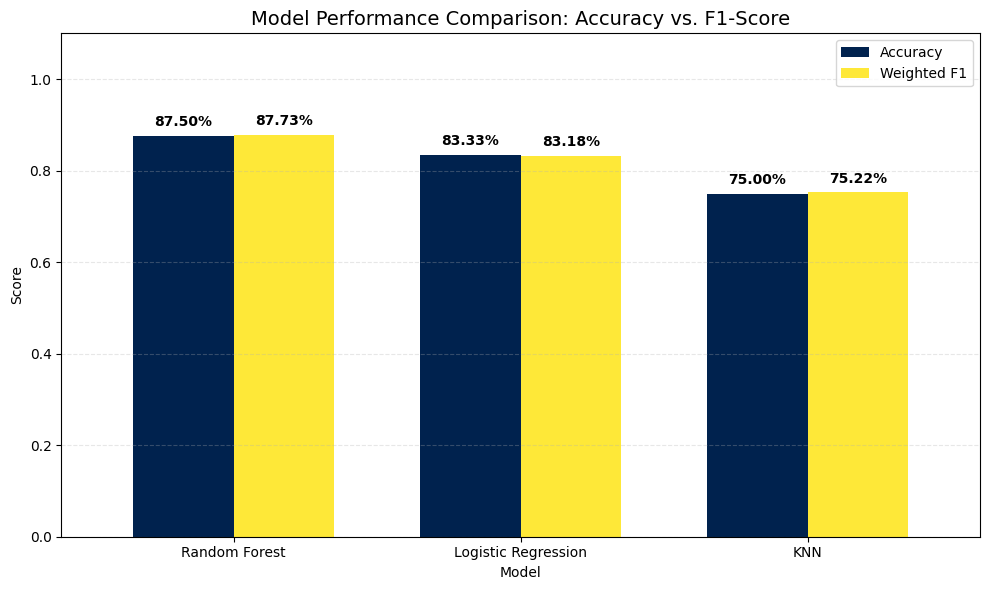

In [ ]:
comparison_data = []

# Metrics for Random Forest
comparison_data.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Weighted F1': f1_score(y_test, y_pred_rf, average='weighted')
})

# Metrics for Logistic Regression
comparison_data.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Weighted F1': f1_score(y_test, y_pred_lr, average='weighted')
})

# Metrics for KNN
comparison_data.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Weighted F1': f1_score(y_test, y_pred_knn, average='weighted')
})

# 2. Create a DataFrame for easy plotting
df_compare = pd.DataFrame(comparison_data).set_index('Model')

# 3. Plot the comparison
ax = df_compare.plot(kind='bar', figsize=(10, 6), colormap='cividis', width=0.7)
plt.title('Model Performance Comparison: Accuracy vs. F1-Score', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# **LLM**

In [42]:
# ==========================================
# LLM DIAGNOSTIC PIPELINE (TEXTUALIZATION)
# ==========================================

def generate_llm_clinical_prompt(row, actual_label=None):
    """
    Converts a single row of symptom data into a
    clinical case study prompt for an LLM.
    """
    # Create the narrative
    narrative = (
        f"PATIENT PROFILE:\n"
        f"- Mood State: The patient reports feeling sad '{row['Sadness']}' and euphoric '{row['Euphoric']}'.\n"
        f"- Physical Symptoms: They are '{row['Exhausted']}' and have a sleep disorder frequency of '{row['Sleep dissorder']}'.\n"
        f"- Behavioral Indicators: Mood swings: {row['Mood Swing']}, Suicidal thoughts: {row['Suicidal thoughts']}, "
        f"Anorexia: {row['Anorxia']}.\n"
        f"- Mental Outlook: Optimism level is {row['Optimisim']}/10, Concentration is {row['Concentration']}/10.\n"
    )

    # Define the System Instruction
    instruction = (
        "INSTRUCTION: You are a clinical psychiatric expert. Based on the DSM-5 criteria and the patient "
        "profile provided above, choose the most likely diagnosis from: [Normal, Bipolar Type-1, Bipolar Type-2, Depression]. "
        "Provide a concise 'Reasoning' section for your choice."
    )

    full_prompt = f"{narrative}\n{instruction}"
    return full_prompt

# 1. Select a few sample cases from your test set to analyze
samples_to_analyze = X_test.head(3)

print("--- GENERATED LLM PROMPTS FOR CLINICAL REASONING ---\n")

for i in range(len(samples_to_analyze)):
    row = samples_to_analyze.iloc[i]
    true_diag = class_names[y_test.iloc[i]] # Get the actual label for comparison

    prompt = generate_llm_clinical_prompt(row)

    print(f"--- CASE {i+1} ---")
    print(prompt)
    print(f"\n[Ground Truth (Actual): {true_diag}]")
    print("-" * 50 + "\n")



--- GENERATED LLM PROMPTS FOR CLINICAL REASONING ---

--- CASE 1 ---
PATIENT PROFILE:
- Mood State: The patient reports feeling sad '2' and euphoric '3'.
- Physical Symptoms: They are '2' and have a sleep disorder frequency of '1'.
- Behavioral Indicators: Mood swings: 0, Suicidal thoughts: 0, Anorexia: 0.
- Mental Outlook: Optimism level is 5/10, Concentration is 4/10.

INSTRUCTION: You are a clinical psychiatric expert. Based on the DSM-5 criteria and the patient profile provided above, choose the most likely diagnosis from: [Normal, Bipolar Type-1, Bipolar Type-2, Depression]. Provide a concise 'Reasoning' section for your choice.

[Ground Truth (Actual): Normal]
--------------------------------------------------

--- CASE 2 ---
PATIENT PROFILE:
- Mood State: The patient reports feeling sad '2' and euphoric '4'.
- Physical Symptoms: They are '2' and have a sleep disorder frequency of '1'.
- Behavioral Indicators: Mood swings: 0, Suicidal thoughts: 0, Anorexia: 1.
- Mental Outlook: O